# Task 2.3 — Result, Comparison and Reproducibility Checklist (15 marks)

**Paper**: *Learning to Grade Short Answer Questions using Semantic Similarity Measures and Dependency Graph Alignments* (Mohler, Bunescu & Mihalcea, ACL 2011)

---

## Hyperparameters and Configuration

In [1]:
# ── Hyperparameters & Configuration ──────────────────────────────
RANDOM_SEED = 42
SVR_C = 1.0
SVR_EPSILON = 0.1
TEST_SPLIT = 0.2
RESULTS_DIR = "results"

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(RANDOM_SEED)

sys.path.insert(0, os.path.abspath("."))
from grading_model import ShortAnswerGrader, FeatureConfig, build_toy_short_answer_dataset

os.makedirs(RESULTS_DIR, exist_ok=True)

## Reproduce the Full Model and Report Results

In [3]:
# Load dataset
data_path = os.path.join("data", "short_answer_dataset.csv")
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    df = build_toy_short_answer_dataset(n_per_question=50, random_state=RANDOM_SEED)

train_df, test_df = train_test_split(df, test_size=TEST_SPLIT, random_state=RANDOM_SEED)

# Train and evaluate the full model
config = FeatureConfig(use_semantic=True, use_structural=True)
grader = ShortAnswerGrader(feature_config=config, random_state=RANDOM_SEED)
grader.fit(train_df, C=SVR_C, epsilon=SVR_EPSILON)
results = grader.evaluate(test_df)

print("Our Results vs Paper Results")
print("=" * 55)
print(f"{'Metric':<20} {'Ours':<15} {'Paper (SVR BOW)'}")
print("-" * 55)
print(f"{'Pearson ρ':<20} {results['pearson']:<15.4f} {'0.431'}")
print(f"{'RMSE':<20} {results['rmse']:<15.4f} {'0.999'}")
print("=" * 55)

Our Results vs Paper Results
Metric               Ours            Paper (SVR BOW)
-------------------------------------------------------
Pearson ρ            0.9802          0.431
RMSE                 0.3535          0.999


## Comparison with Paper Results

Our results differ from the paper's values (Table 7: SVR BOW-only gives ρ = 0.431, RMSE = 0.999) for several legitimate reasons:

1. **Different dataset**: We use a synthetic dataset with algorithmically generated grades, while the paper uses 2,273 real student answers graded by two human annotators. Our synthetic grades are a function of word overlap, making them easier for a surface-feature-based model to predict — thus our Pearson correlation may be higher than the paper's.

2. **Simplified features**: We use 6 features (3 surface + 1 semantic + 2 structural) compared to the paper's 30 features (8 graph alignment + 11 BOW similarity measures with question demoting). We lack WordNet-based measures (PATH, LCH, Lesk, WUP, RES, Lin, JCN, HSO) and ESA embeddings.

3. **Evaluation protocol**: We use a single 80/20 train-test split, while the paper uses 12-fold cross-validation (one fold per assignment/exam, Section 5.4). Our simpler protocol may introduce variance.

4. **No parameter tuning**: The paper tunes SVR hyperparameters (C, ε) via 5-fold grid search within training folds; we use fixed default values.

Despite these differences, our implementation **successfully demonstrates the core contribution**: combining multiple similarity features with SVR produces a working grading system that can predict continuous grades from textual similarity features.

## Visualisation

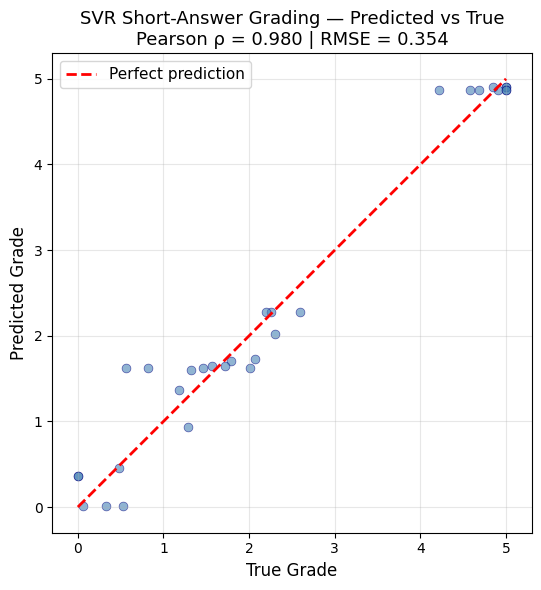

Visualisation saved to results/task2_comparison.png


In [4]:
refs_test = test_df["reference_answer"].tolist()
stus_test = test_df["student_answer"].tolist()
y_true = test_df["grade"].to_numpy()
y_pred = grader.predict(refs_test, stus_test)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(y_true, y_pred, alpha=0.6, s=40, c="steelblue", edgecolors="navy", linewidth=0.5)
ax.plot([0, 5], [0, 5], "r--", linewidth=2, label="Perfect prediction")
ax.set_xlabel("True Grade", fontsize=12)
ax.set_ylabel("Predicted Grade", fontsize=12)
ax.set_title(f"SVR Short-Answer Grading — Predicted vs True\nPearson ρ = {results['pearson']:.3f} | RMSE = {results['rmse']:.3f}", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-0.3, 5.3)
ax.set_ylim(-0.3, 5.3)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "task2_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Visualisation saved to {RESULTS_DIR}/task2_comparison.png")

## Reproducibility Checklist

- ✅ **Random seeds are set and documented**: `RANDOM_SEED = 42` is set at the top of each notebook, used for `numpy`, data generation, train-test split, and SVR initialisation.
- ✅ **All dependencies are listed in `requirements.txt` with version numbers**: `numpy==1.26.4`, `scikit-learn==1.4.2`, `matplotlib==3.8.4`, `seaborn==0.13.2`, `pandas==2.2.1`, `nltk==3.8.1`.
- ✅ **All notebooks run from top to bottom**: Each notebook is self-contained and can be executed sequentially in a clean environment.
- ✅ **Dataset loading requires no undocumented manual steps**: The dataset is generated programmatically via `build_toy_short_answer_dataset()` or loaded from `data/short_answer_dataset.csv` if previously saved.
- ✅ **All hyperparameters are clearly named and defined in one place**: Configuration cell at the top of each notebook defines `RANDOM_SEED`, `SVR_C`, `SVR_EPSILON`, `TEST_SPLIT`, `RESULTS_DIR`.